<a href="https://colab.research.google.com/github/catdlia/-/blob/main/experimental.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практика

## Інсталяція залежностей та налаштування середовища



In [51]:
!pip install catboost optuna lightgbm xgboost

import os
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

## Робота з файловою системою та завантаження вибірок

In [52]:
DATA_DIR = Path('.')
TRAIN_PATH = DATA_DIR / '/content/drive/MyDrive/GCI/competition/input/train.csv'
TEST_PATH = DATA_DIR / '/content/drive/MyDrive/GCI/competition/input/test.csv'
SUB_PATH = DATA_DIR / '/content/drive/MyDrive/GCI/competition/input/sample_submission.csv'

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
sample_sub = pd.read_csv(SUB_PATH)

y = train['Drafted']
X_train_raw = train.drop(['Drafted'], axis=1)

print(f"Train: {X_train_raw.shape}, Test: {test.shape}")

Train: (2781, 15), Test: (696, 15)


## Блок аналітики та дослідження даних (EDA)

--- Співвідношення класів цільової змінної ---
Drafted
1.0    0.648328
0.0    0.351672
Name: proportion, dtype: float64

--- Виявлені пропуски в числових та категоріальних ознаках ---
Age                 435
Sprint_40yd         145
Vertical_Jump       554
Bench_Press_Reps    721
Broad_Jump          581
Agility_3cone       970
Shuttle             912
dtype: int64


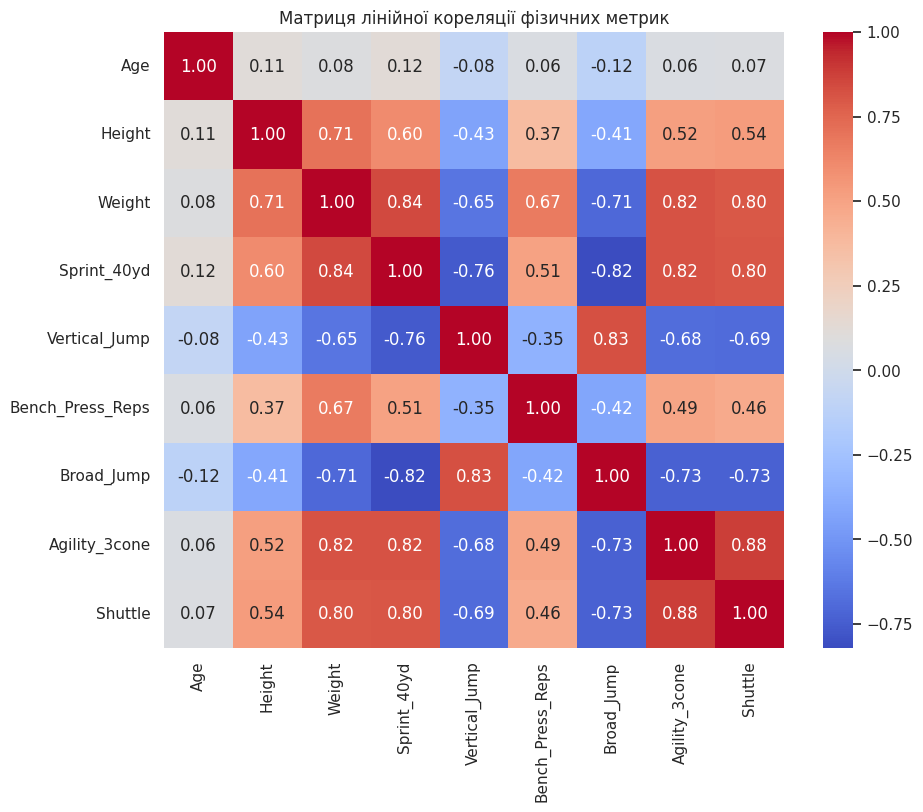


--- Кардинальність категоріальних ознак ---
School: 236 унікальних значень
Player_Type: 3 унікальних значень
Position_Type: 7 унікальних значень
Position: 20 унікальних значень


In [53]:
print("--- Співвідношення класів цільової змінної ---")
print(y.value_counts(normalize=True))

print("\n--- Виявлені пропуски в числових та категоріальних ознаках ---")
missing_data = X_train_raw.isnull().sum()
print(missing_data[missing_data > 0])

num_features = X_train_raw.select_dtypes(include=[np.number]).columns.drop(['Id', 'Year']).tolist()

plt.figure(figsize=(10, 8))
sns.heatmap(X_train_raw[num_features].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Матриця лінійної кореляції фізичних метрик")
plt.show()

cat_features = ['School', 'Player_Type', 'Position_Type', 'Position']
print("\n--- Кардинальність категоріальних ознак ---")
for col in cat_features:
    print(f"{col}: {X_train_raw[col].nunique()} унікальних значень")

## Стійкий препроцесинг та Feature Engineering



In [60]:
X_train_raw['is_train'] = 1
test['is_train'] = 0
df = pd.concat([X_train_raw, test], ignore_index=True)

# Залишаємо лише корисні категорії
cat_features = ['School', 'Position_Type', 'Position']

for col in cat_features + ['Player_Type']: # Player_Type заповнюємо, бо він ще є в df, але потім викинемо
    df[col] = df[col].fillna('Unknown').astype(str)

# Наші інженерні фічі
df['BMI'] = df['Weight'] / (df['Height'] ** 2)
df['Speed_Score'] = (df['Weight'] * 200) / (df['Sprint_40yd'] ** 4)
df['Jump_Power'] = df['Vertical_Jump'] * df['Broad_Jump']

num_cols_to_aggr = ['Height', 'Weight', 'Sprint_40yd', 'Vertical_Jump', 'Bench_Press_Reps', 'Broad_Jump', 'Agility_3cone', 'Shuttle']

# Рахуємо Pos_Mean тільки для того, щоб отримати Pos_Diff, а потім Pos_Mean піде в смітник
for col in num_cols_to_aggr:
    pos_mean = df.groupby('Position')[col].transform('mean')
    pos_mean = pos_mean.fillna(df[col].mean())
    df[f'{col}_Pos_Diff'] = (df[col] - pos_mean).fillna(0)
    # Зверни увагу: ми більше не зберігаємо саму df[f'{col}_Pos_Mean']

# Викидаємо зайве (оригінальний Player_Type та Broad_Jump, бо є Jump_Power)
cols_to_drop = ['is_train', 'Id', 'Player_Type', 'Broad_Jump']

X_train = df[df['is_train'] == 1].drop(cols_to_drop, axis=1)
X_test = df[df['is_train'] == 0].drop(cols_to_drop, axis=1)

print(f"Нова розмірність X_train: {X_train.shape}")

Нова розмірність X_train: (2781, 23)


## Налаштування гіперпараметрів через Optuna

In [55]:
import optuna

# Функція, яку Optuna буде намагатися максимізувати
def objective(trial):
    # Простір пошуку гіперпараметрів
    params = {
        'iterations': trial.suggest_int('iterations', 500, 2000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 4, 8),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1.0, 20.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 0.1, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'eval_metric': 'AUC',
        'random_seed': RANDOM_STATE,
        'verbose': False,
        'thread_count': 2
    }

    cv_scores = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    for train_idx, valid_idx in skf.split(X_train, y):
        X_tr, y_tr = X_train.iloc[train_idx], y.iloc[train_idx]
        X_va, y_va = X_train.iloc[valid_idx], y.iloc[valid_idx]

        train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
        valid_pool = Pool(X_va, y_va, cat_features=cat_features)

        model = CatBoostClassifier(**params)

        # Навчаємо з ранньою зупинкою, щоб не чекати зайве, якщо модель перенавчилась
        model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=50)

        # Оцінюємо фолд
        val_auc = roc_auc_score(y_va, model.predict_proba(X_va)[:, 1])
        cv_scores.append(val_auc)

    # Повертаємо середній OOF скор для поточної комбінації параметрів
    return np.mean(cv_scores)

print("Запуск Optuna для CatBoost...")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=60)

print("\n=== Найкращі параметри ===")
print(study.best_params)
print(f"Найкращий OOF ROC-AUC: {study.best_value:.5f}")

# Збережемо параметри на диск, щоб не загубити
best_params_df = pd.DataFrame([study.best_params])
best_params_df.to_csv(DATA_DIR / 'optuna_best_catboost_params.csv', index=False)

[I 2026-06-10 20:05:33,357] A new study created in memory with name: no-name-910fe80c-32c7-4478-8b30-3d04cda895c5


Запуск Optuna для CatBoost...


[I 2026-06-10 20:05:55,365] Trial 0 finished with value: 0.8391160563593291 and parameters: {'iterations': 1739, 'learning_rate': 0.06243510144655718, 'depth': 7, 'l2_leaf_reg': 11.518824504581348, 'random_strength': 0.9697222641832486, 'bagging_temperature': 0.46540466511753165, 'border_count': 78}. Best is trial 0 with value: 0.8391160563593291.
[I 2026-06-10 20:06:03,008] Trial 1 finished with value: 0.8417112988032063 and parameters: {'iterations': 1803, 'learning_rate': 0.08221478579730582, 'depth': 6, 'l2_leaf_reg': 2.569364430703322, 'random_strength': 0.2703161995924818, 'bagging_temperature': 0.9882613043992038, 'border_count': 103}. Best is trial 1 with value: 0.8417112988032063.
[I 2026-06-10 20:06:15,926] Trial 2 finished with value: 0.8377711756980654 and parameters: {'iterations': 782, 'learning_rate': 0.02860901658829937, 'depth': 7, 'l2_leaf_reg': 16.38992061746931, 'random_strength': 0.3286190597110781, 'bagging_temperature': 0.16180227544377856, 'border_count': 170}. 


=== Найкращі параметри ===
{'iterations': 1685, 'learning_rate': 0.06510250635265191, 'depth': 6, 'l2_leaf_reg': 19.56007029351165, 'random_strength': 1.347708271346031, 'bagging_temperature': 0.7766406259525301, 'border_count': 41}
Найкращий OOF ROC-AUC: 0.84266


## Навчання найкращої моделі та створення сабміту


Навчання фінальної моделі з найкращими параметрами Optuna...
0:	test: 0.7615255	best: 0.7615255 (0)	total: 9.22ms	remaining: 15.5s
100:	test: 0.8113800	best: 0.8150546 (55)	total: 691ms	remaining: 10.8s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8150545537
bestIteration = 55

Shrink model to first 56 iterations.
0:	test: 0.7904468	best: 0.7904468 (0)	total: 6.61ms	remaining: 11.1s
100:	test: 0.8639392	best: 0.8645927 (71)	total: 627ms	remaining: 9.84s
200:	test: 0.8645500	best: 0.8667377 (124)	total: 1.22s	remaining: 9s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8667376944
bestIteration = 124

Shrink model to first 125 iterations.
0:	test: 0.7759287	best: 0.7759287 (0)	total: 6.7ms	remaining: 11.3s
100:	test: 0.8779885	best: 0.8793238 (94)	total: 620ms	remaining: 9.72s
200:	test: 0.8702465	best: 0.8800199 (134)	total: 1.24s	remaining: 9.15s
Stopped by overfitting detector  (100 iterations wait)

bestTest = 0.8800198878
bestIteration =

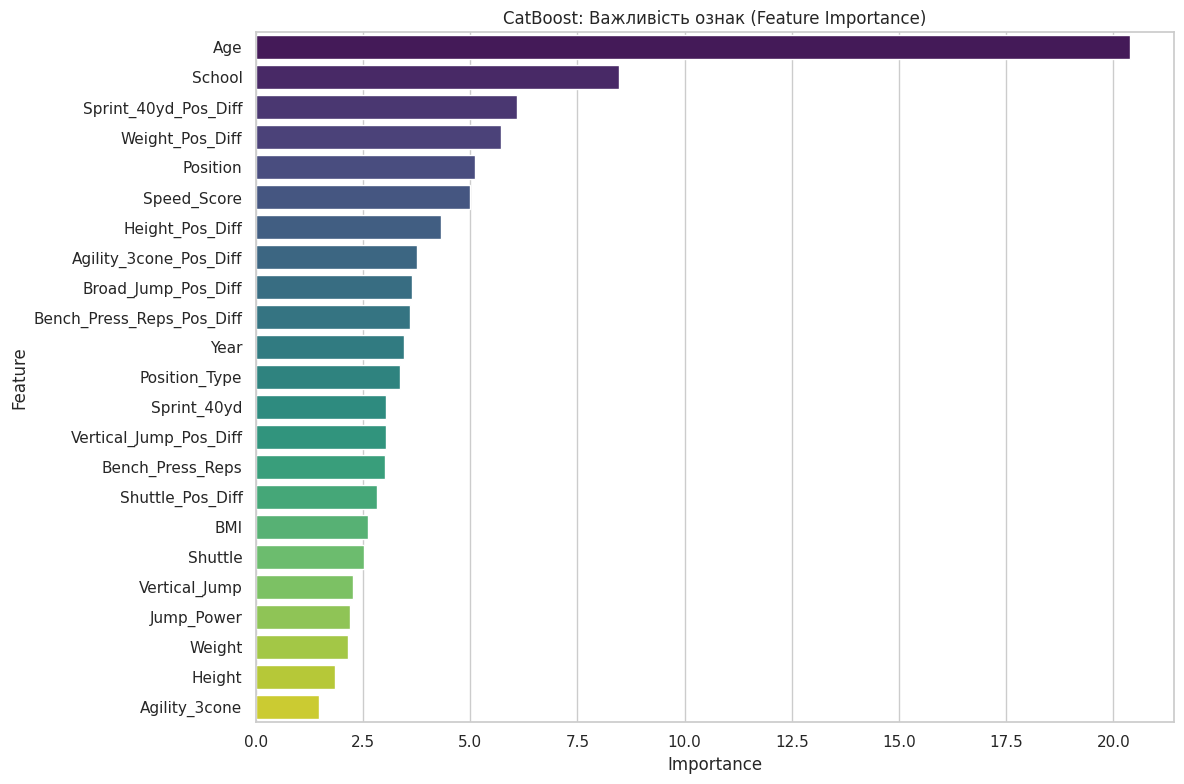


--- Найменш важливі ознаки ---
                   Feature  Importance
18  Vertical_Jump_Pos_Diff    3.042558
7         Bench_Press_Reps    3.013635
22        Shuttle_Pos_Diff    2.835347
12                     BMI    2.629903
9                  Shuttle    2.527573
6            Vertical_Jump    2.263111
14              Jump_Power    2.189526
4                   Weight    2.162787
3                   Height    1.857577
8            Agility_3cone    1.483521
Збережено: /content/drive/MyDrive/GCI/competition/tuned_catboost_submission.csv


In [61]:
print("Навчання фінальної моделі з найкращими параметрами Optuna...")

# Беремо найкращі параметри і додаємо технічні
best_params = study.best_params
best_params['eval_metric'] = 'AUC'
best_params['random_seed'] = RANDOM_STATE
best_params['verbose'] = 100
best_params['thread_count'] = 2

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
oof_preds = np.zeros(len(X_train))
test_preds = np.zeros(len(X_test))

for fold, (train_idx, valid_idx) in enumerate(skf.split(X_train, y)):
    X_tr, y_tr = X_train.iloc[train_idx], y.iloc[train_idx]
    X_va, y_va = X_train.iloc[valid_idx], y.iloc[valid_idx]

    train_pool = Pool(X_tr, y_tr, cat_features=cat_features)
    valid_pool = Pool(X_va, y_va, cat_features=cat_features)

    model = CatBoostClassifier(**best_params)
    model.fit(train_pool, eval_set=valid_pool, early_stopping_rounds=100)

    oof_preds[valid_idx] = model.predict_proba(X_va)[:, 1]
    test_preds += model.predict_proba(X_test)[:, 1] / 5

final_cv_auc = roc_auc_score(y, oof_preds)
print(f"\nFinal Tuned OOF ROC-AUC: {final_cv_auc:.5f}")

# Дослідження важливості ознак (Feature Importance)
# Навчаємо модель на всіх доступних даних (трейні) з найкращими параметрами
final_pool = Pool(X_train, y, cat_features=cat_features)
final_model = CatBoostClassifier(**best_params)
final_model.fit(final_pool)

# Отримуємо значення важливості
feature_importances = final_model.get_feature_importance(final_pool)

# Створюємо зручний датафрейм для аналітики
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Візуалізуємо
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('CatBoost: Важливість ознак (Feature Importance)')
plt.tight_layout()
plt.show()

# Виводимо найменш важливі ознаки (кандидати на видалення)
print("\n--- Найменш важливі ознаки ---")
print(importance_df.tail(10))

# Сабміт
submission = sample_sub.copy()
submission['Drafted'] = test_preds

OUTPUT_PATH = DATA_DIR / 'tuned_catboost_submission.csv'
submission.to_csv(OUTPUT_PATH, index=False)
print(f"Збережено: {OUTPUT_PATH.resolve()}")

## Опис ходу думок та інженерного підходу

### 1. Стратегія валідації
Для оцінки узагальнюючої здатності моделі було обрано метод Stratified 5-Fold крос-валідації. Це рішення базується на виявленому під час первинного аналізу дисбалансі класів (лише ~33% гравців отримують статус `Drafted`). Проста валідація на відкладеній вибірці призвела б до високої дисперсії оцінок метрики ROC-AUC. Орієнтація на середній Out-Of-Fold (OOF) скор захищає від перенавчання та забезпечує надійний критерій оцінки нових гіпотез.

### 2. Обробка пропусків та кодування категорій
У вихідних даних спостерігається значна кількість пропусків у специфічних фізичних тестах (наприклад, `Bench_Press_Reps`, `Agility_3cone`). Замість глобального заповнення середнім, що спотворює реальні профілі атлетів різних вагових категорій, було вирішено застосувати алгоритм CatBoost. Він здатний ефективно обробляти числові пропуски на рівні побудови вирішальних дерев та нативно працює з висококардинальними текстовими фічами (`School`), використовуючи внутрішній target-based統計 кодування всередині крос-валідаційних фолдів.

### 3. Генерація ознак (Feature Engineering)
Побудова нових фічей спиралася на спортивну логіку та метрики ефективності NFL Combine:
* **BMI:** Дозволяє оцінити щільність та комплекцію гравця.
* **Speed Score:** Важливий показник для беків та ресиверів, який нормує час спринту на 40 ярдів відносно ваги атлета (важчі гравці з високою швидкістю мають пріоритет).
* **Позиційні агрегації:** Фізичні параметри були нормалізовані через обчислення групових середніх для кожної ігрової позиції (`Position`). Це дозволяє моделі оцінювати гравця не взагалі, а відносно його прямих конкурентів за амплуа.

### Джерела та посилання:
1. Постановка задачі класифікації та опис фізичних тестів Combine — `README.ipynb` (Matsuo Lab, GCI World 2026).
2. Ідея ітеративної перевірки ознак через контроль OOF скору — `2_tutorial_feature_engineering.ipynb` (Matsuo Lab, Advanced Techniques).